# Cross-Validation

Validation in machine learning is the process of evaluating a model’s performance on unseen data to ensure it generalizes well and meets its intended purpose.

Cross-validation is a resampling technique that evaluates a model’s ability to generalize by repeatedly training on subsets of data and validating on the remaining parts, most commonly using methods like k‑fold, stratified, and leave‑one‑out cross‑validation. It helps prevent overfitting and provides a more reliable estimate of model performance on unseen data.

In [100]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [101]:
#load mtcars
dfcars=pd.read_csv("mtcars.csv")
dfcars=dfcars.rename(columns={"Unnamed: 0":"name"})
dfcars.head()

,name,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [102]:
y = dfcars['mpg']

In [103]:
allX = dfcars.iloc[:, 2:]

In [104]:
allX.head()

,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [105]:
from sklearn.model_selection import train_test_split

In [106]:
from sklearn.model_selection import cross_val_score

In [107]:
from sklearn.linear_model import LinearRegression

In [108]:
allX_train, allX_test, y_train, y_test = train_test_split(allX, y, test_size=0.2, random_state=42)

## Weight

In [109]:
X_train = allX_train[["wt"]]
X_test = allX_test[["wt"]]

In [110]:
model5 = LinearRegression()
scores = cross_val_score(model5, X_train, y_train)
scores

array([0.10736385, 0.49488149, 0.86879651, 0.65179584, 0.73272638])

In [111]:
scores.mean()

np.float64(0.5711128154689782)

## Weight & HP

In [112]:
X_train = allX_train[["wt","hp"]]
X_test = allX_test[["wt","hp"]]

In [113]:
model6 = LinearRegression()
scores6 = cross_val_score(model5, X_train, y_train)
scores6

array([0.1262545 , 0.6744817 , 0.76712479, 0.76448681, 0.83404541])

In [114]:
scores6.mean()

np.float64(0.6332786406507418)

## Weight, HP & Drat

In [115]:
X_train = allX_train[["wt","hp","drat"]]
X_test = allX_test[["wt","hp","drat"]]

In [116]:
model7 = LinearRegression()
scores7 = cross_val_score(model5, X_train, y_train)
scores7.mean()

np.float64(0.6571279909053496)

##  Weight, HP & Carb

In [117]:
X_train = allX_train[["wt","hp","carb"]]
X_test = allX_test[["wt","hp","carb"]]

In [118]:
model8 = LinearRegression()
scores8 = cross_val_score(model5, X_train, y_train)
scores8.mean()

np.float64(0.6036599344425266)

## Weight, HP & Drat model

In [119]:
X_train = allX_train[["wt","hp","drat"]]
X_test = allX_test[["wt","hp","drat"]]
model7 = LinearRegression()
model7.fit(X_train, y_train)
model7.score(X_test, y_test)

0.7900492843805197

# Polynomial Regression

Pick one variable and see if a Polynomial Regression model could improve that one variable

In [120]:
from sklearn import datasets
diabetes = datasets.load_diabetes() #Import dataset and divide into X and y 
print(diabetes.DESCR)
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [121]:
#Try some feature combinations
selected_features = ['sex', 'bmi', 'bp', 's3', 's5']
X_subset = X[selected_features].values

#Split the data into training and testing sets 
X_train, X_test, y_train, y_test = train_test_split(X_subset, y, test_size=0.2, random_state=10)

Define range of degrees and evaluate polynomial regression for each degree to find which is best fit for the data. Run cross-validation to make decision on best d based on validation (rather than on test set). 

In [122]:
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures 

In [123]:
degrees = range(1, 6)  #Testing different polynomial degrees 
train_mean_scores = []  #Stores cross-validation R2 scores for each degree
test_scores = []        #Stores test set R2 scores for each degree
error_train = []        #Stores MSE for the training set for each degree
error_test = []        #Stores MSE for the test set for each degree

#Evaluate each degree by creating a polynomial regression model run cross-validation
for d in degrees:
    #Calculate the poly features
    X_train_poly = PolynomialFeatures(d).fit_transform(X_train)
    X_test_poly = PolynomialFeatures(d).fit_transform(X_test)
    model = LinearRegression()
    
    #Perform cross-validation on the training set and get the R2 score as above
    train_scores = cross_val_score(model, X_train_poly, y_train)
    train_score = train_scores.mean()
    train_mean_scores.append(train_score)
    
    #Fit the model on the poly training set and score on the poly test set
    model.fit(X_train_poly, y_train)
    mse_train = mean_squared_error(model.predict(X_train_poly), y_train)
    error_train.append(mse_train)    #Record MSE for training set
    test_score = model.score(X_test_poly, y_test)
    mse_test = mean_squared_error(model.predict(X_test_poly), y_test)
    error_train.append(mse_test)    #Record MSE for test set
    test_scores.append(test_score)
    
    #Display the train and test scores for each degree
    print(f"Degree {d}: Train CV Mean R^2 Score = {train_score:.3f}, Test R^2 Score = {test_score:.3f}, TRain MSE = {mse_train:.3f}, Test MSE = {mse_test:.3f}")


Degree 1: Train CV Mean R^2 Score = 0.479, Test R^2 Score = 0.521, TRain MSE = 2895.318, Test MSE = 2995.469
Degree 2: Train CV Mean R^2 Score = 0.487, Test R^2 Score = 0.472, TRain MSE = 2644.944, Test MSE = 3302.176
Degree 3: Train CV Mean R^2 Score = 0.327, Test R^2 Score = 0.412, TRain MSE = 2421.176, Test MSE = 3674.640
Degree 4: Train CV Mean R^2 Score = -2.804, Test R^2 Score = 0.254, TRain MSE = 2119.738, Test MSE = 4666.373
Degree 5: Train CV Mean R^2 Score = -231.821, Test R^2 Score = -4.943, TRain MSE = 1404.277, Test MSE = 37150.916


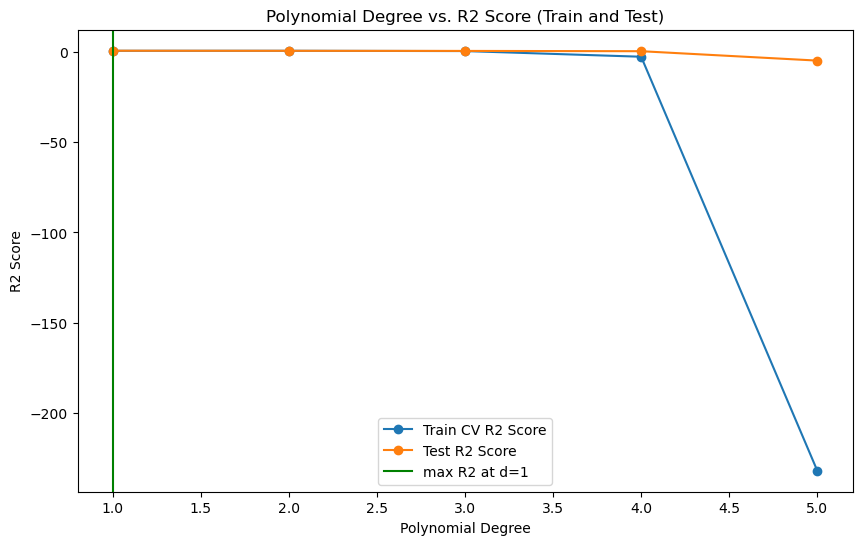

The optimal polynomial degree is 1 with a test R2 score of 0.521.


In [124]:
#Plot results 
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_mean_scores, marker='o', label='Train CV R2 Score')
plt.plot(degrees, test_scores, marker='o', label='Test R2 Score')
plt.xlabel('Polynomial Degree')
plt.ylabel('R2 Score')
plt.title('Polynomial Degree vs. R2 Score (Train and Test)')

#Find and display the best degree with the best R2 score on the test set
bestd = degrees[np.argmax(test_scores)]
plt.axvline(bestd, 0,1, color='g', label="max R2 at d=%d"%bestd)
plt.legend()
plt.show()
print(f"The optimal polynomial degree is {bestd} with a test R2 score of {max(test_scores):.3f}.")


The results above show that linear regression (degree 1) has superior performance than polynomial regression for the features I tested in the diabetes dataset. This means that the data likely follows a linear distribution.

#